# Лабораторная работа 1
## Анализ и прогнозирование временных рядов на примере розничных продаж

**Данные:** `retail_sales_mock_data.csv`  \n**Цель:** провести EDA, декомпозицию, построить и сравнить ARIMA/SARIMAX, выбрать предпочтительную модель.

In [1]:
!nvidia-smi

Tue Mar  3 10:33:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:F1:00.0 Off |                  Off |
| 30%   31C    P8             16W /  600W |       2MiB /  97887MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Установка зависимостей (ячейка безопасна для повторного запуска)
import importlib
import subprocess
import sys

required = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'statsmodels': 'statsmodels',
    'sklearn': 'scikit-learn',
    'scipy': 'scipy',
    'pywt': 'PyWavelets'
}

missing = []
for module_name, package_name in required.items():
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        missing.append(package_name)

if missing:
    print('Устанавливаются пакеты:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
else:
    print('Все зависимости уже установлены.')

Устанавливаются пакеты: ['statsmodels', 'PyWavelets']


In [3]:
# Импорт библиотек и настройки
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt

from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Подготовка и первичная проверка данных

In [4]:
# Загрузка и подготовка временного ряда
df = pd.read_csv('retail_sales_mock_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date').asfreq('MS')

print('Размер данных:', df.shape)
display(df.head())
display(df.describe().T)
print('Пропуски по столбцам:')
display(df.isna().sum())

Размер данных: (48, 3)


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


,count,mean,std,min,25%,50%,75%,max
SalesAmount,48.0,11768.541667,2257.544863,7783.0,10219.75,11851.0,13014.0,17996.0
Promotion,48.0,0.125000,0.334219,0.0,0.00,0.0,0.0,1.0
HolidayMonth,48.0,0.083333,0.279310,0.0,0.00,0.0,0.0,1.0


Пропуски по столбцам:


SalesAmount     0
Promotion       0
HolidayMonth    0
dtype: int64

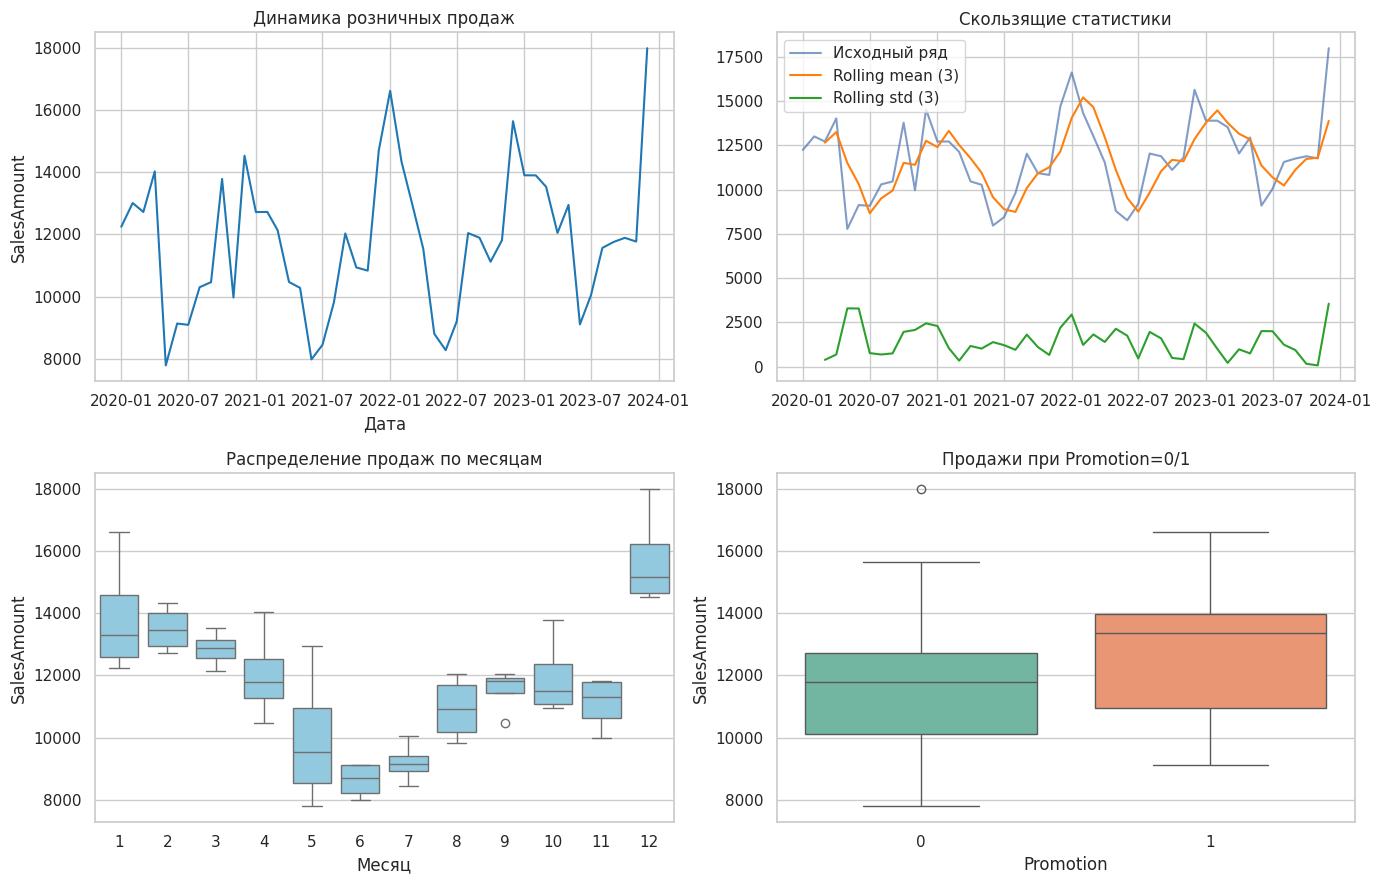

In [5]:
# EDA визуализации
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(df.index, df['SalesAmount'], color='tab:blue')
axes[0, 0].set_title('Динамика розничных продаж')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('SalesAmount')

roll_mean = df['SalesAmount'].rolling(window=3).mean()
roll_std = df['SalesAmount'].rolling(window=3).std()
axes[0, 1].plot(df.index, df['SalesAmount'], label='Исходный ряд', alpha=0.7)
axes[0, 1].plot(df.index, roll_mean, label='Rolling mean (3)', color='tab:orange')
axes[0, 1].plot(df.index, roll_std, label='Rolling std (3)', color='tab:green')
axes[0, 1].set_title('Скользящие статистики')
axes[0, 1].legend()

tmp = df.copy()
tmp['month'] = tmp.index.month
sns.boxplot(data=tmp, x='month', y='SalesAmount', ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Распределение продаж по месяцам')
axes[1, 0].set_xlabel('Месяц')

sns.boxplot(data=df.reset_index(), x='Promotion', y='SalesAmount', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Продажи при Promotion=0/1')

plt.tight_layout()
plt.show()

### Вывод по пункту 1
Ряд ежемесячный, 48 наблюдений (2020-01-01 ... 2023-12-01), заметны сезонные всплески в конце года.
`Promotion` и `HolidayMonth` разумно использовать как экзогенные признаки в SARIMAX.

## 2. Декомпозиция ряда и спектральный анализ

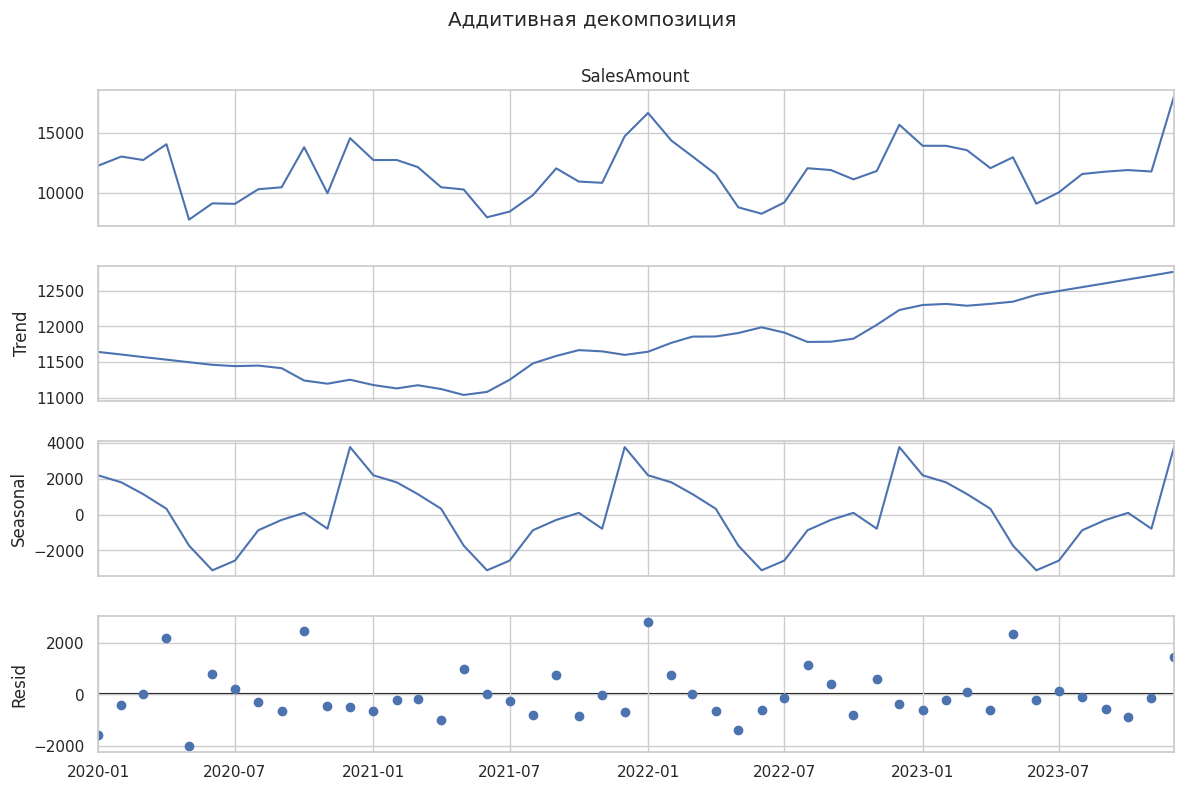

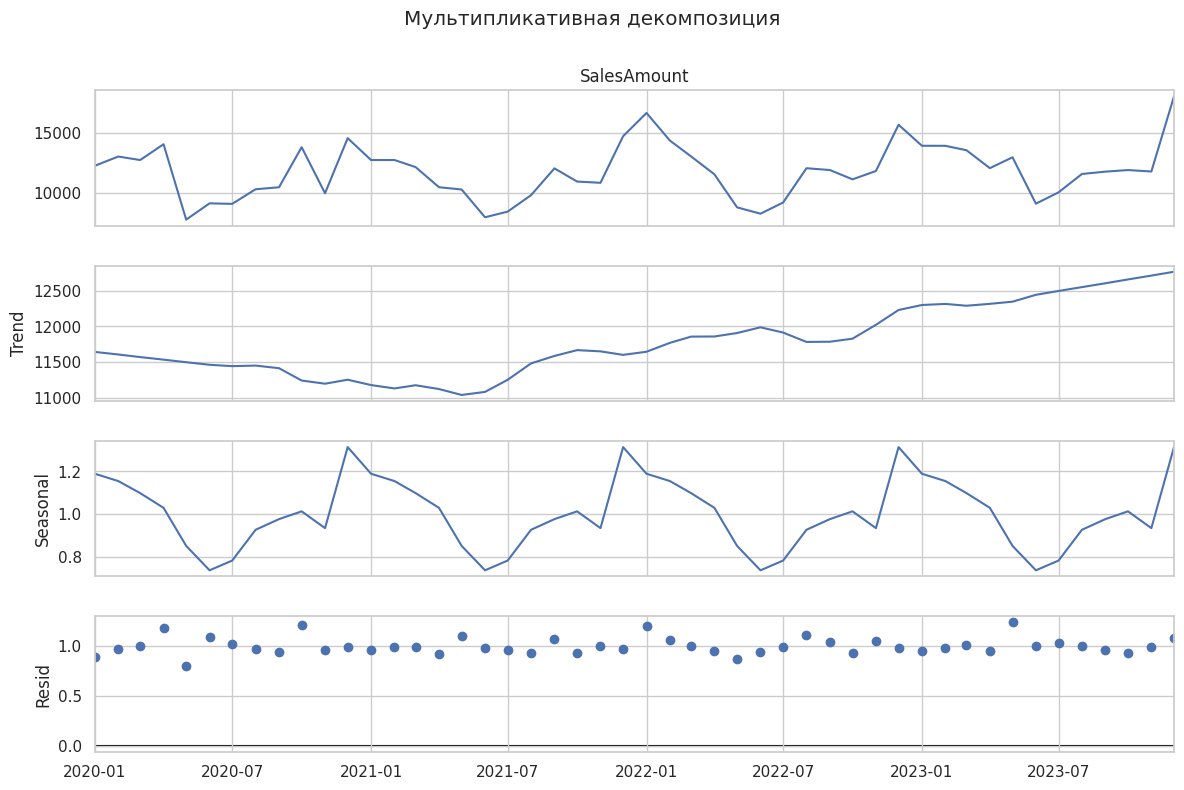

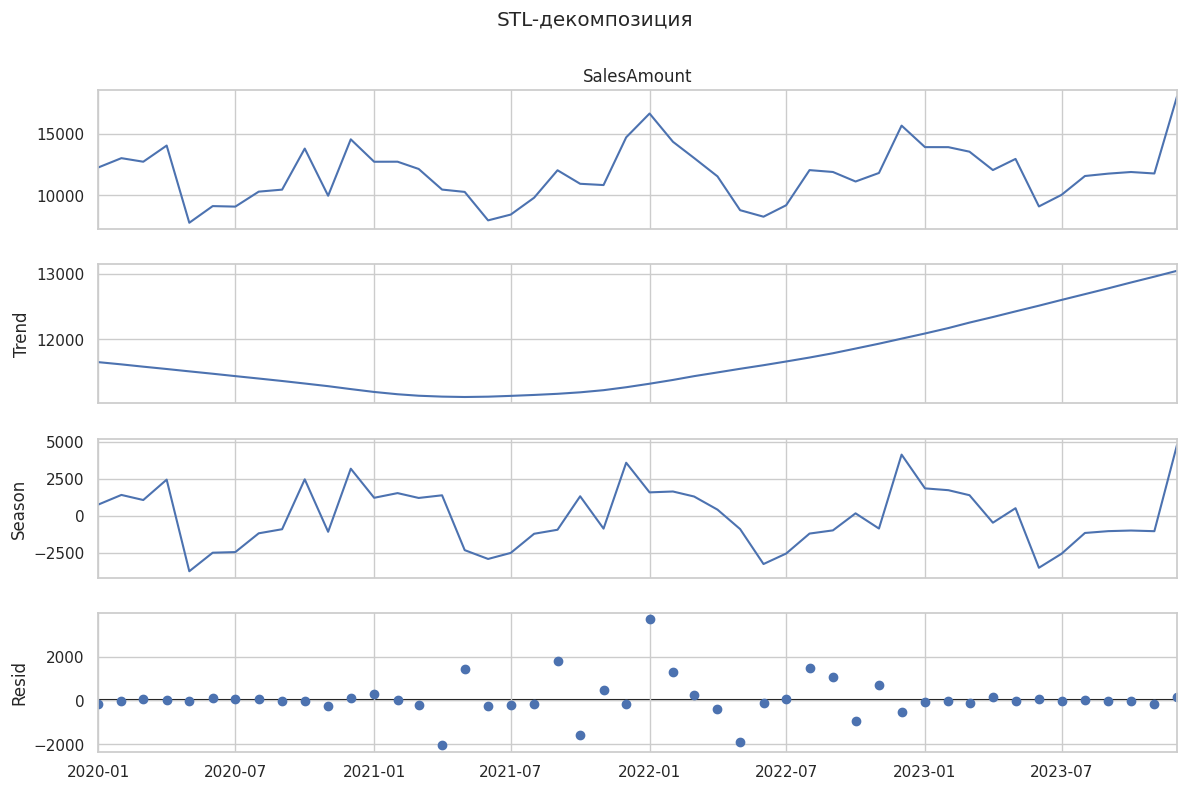

In [6]:
# Классические декомпозиции: аддитивная, мультипликативная и STL
series = df['SalesAmount']
add_decomp = seasonal_decompose(series, model='additive', period=12, extrapolate_trend='freq')
mul_decomp = seasonal_decompose(series, model='multiplicative', period=12, extrapolate_trend='freq')
stl_decomp = STL(series, period=12, robust=True).fit()

fig = add_decomp.plot(); fig.set_size_inches(12, 8); fig.suptitle('Аддитивная декомпозиция', y=1.02); plt.show()
fig = mul_decomp.plot(); fig.set_size_inches(12, 8); fig.suptitle('Мультипликативная декомпозиция', y=1.02); plt.show()
fig = stl_decomp.plot(); fig.set_size_inches(12, 8); fig.suptitle('STL-декомпозиция', y=1.02); plt.show()

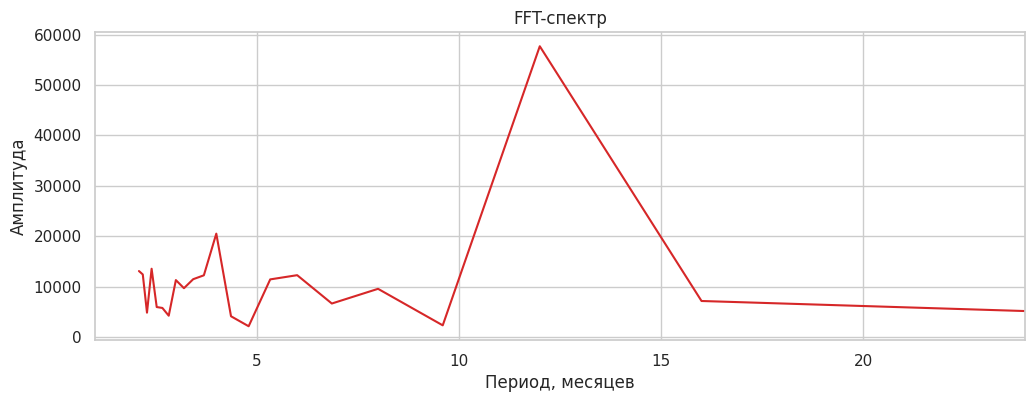

Топ-5 спектральных пиков:


,frequency,period_months,amplitude
0,0.083333,12.0,57678.596627
1,0.250000,4.0,20504.204886
2,0.416667,2.4,13539.812449
3,0.166667,6.0,12263.056593
4,0.333333,3.0,11287.827116


In [7]:
# FFT: поиск доминирующих периодов
n = len(series)
demeaned = series - series.mean()
fft_vals = fft(demeaned.values)
freqs = fftfreq(n, d=1)
mask = freqs > 0
pos_freqs = freqs[mask]
power = np.abs(fft_vals[mask])
periods = 1 / pos_freqs

peak_ids, _ = find_peaks(power)
peak_table = pd.DataFrame({
    'frequency': pos_freqs[peak_ids],
    'period_months': periods[peak_ids],
    'amplitude': power[peak_ids]
}).sort_values('amplitude', ascending=False).head(5)

plt.figure(figsize=(12, 4))
plt.plot(periods, power, color='tab:red')
plt.xlim(1, 24)
plt.xlabel('Период, месяцев')
plt.ylabel('Амплитуда')
plt.title('FFT-спектр')
plt.grid(True)
plt.show()

print('Топ-5 спектральных пиков:')
display(peak_table.reset_index(drop=True))

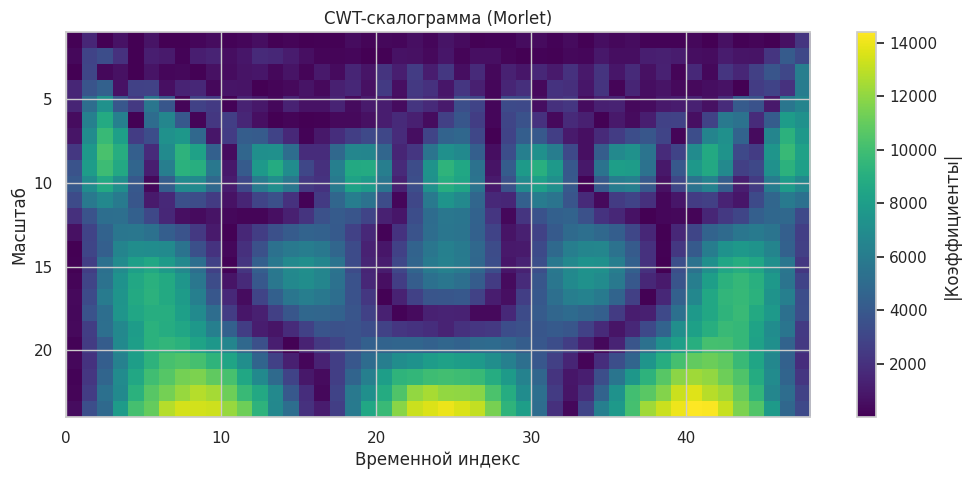

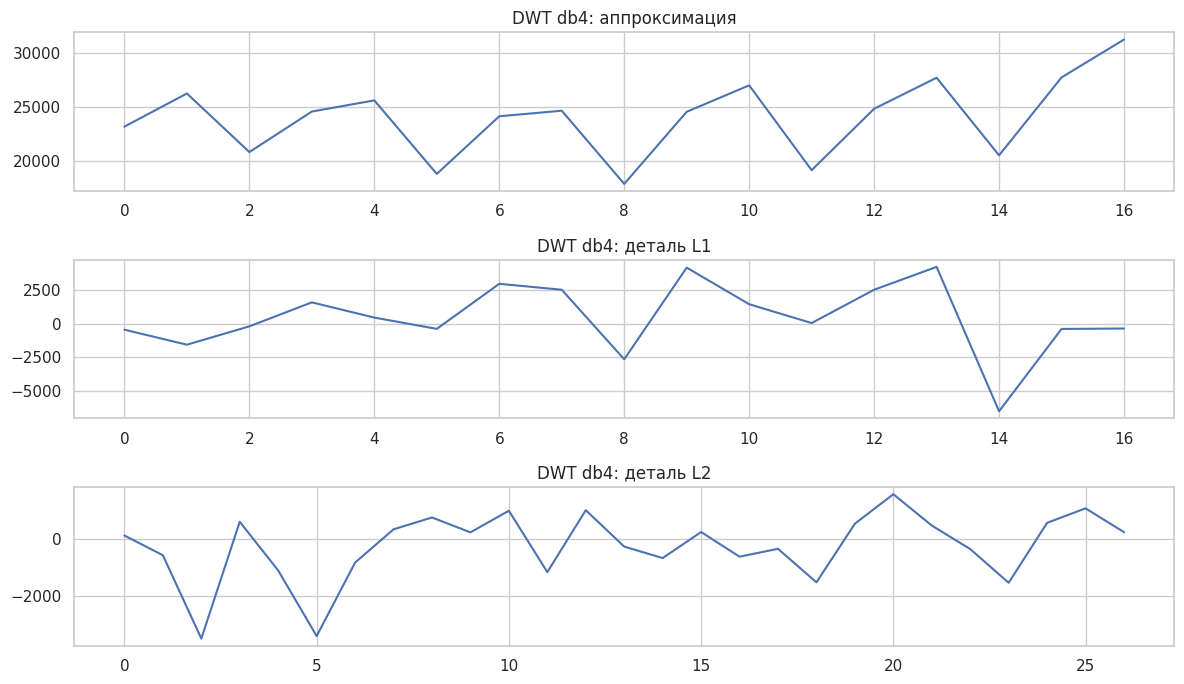

In [8]:
# Вейвлет-анализ: CWT (Morlet) + DWT (Daubechies db4)
values = series.values.astype(float)
scales = np.arange(1, 25)
coeffs, _ = pywt.cwt(values, scales=scales, wavelet='morl')
power_w = np.abs(coeffs)

plt.figure(figsize=(12, 5))
plt.imshow(power_w, extent=[0, len(values), scales.max(), scales.min()], aspect='auto', cmap='viridis')
plt.colorbar(label='|Коэффициенты|')
plt.title('CWT-скалограмма (Morlet)')
plt.xlabel('Временной индекс')
plt.ylabel('Масштаб')
plt.show()

dwt_coeffs = pywt.wavedec(values, wavelet='db4', level=2)
approx, detail1, detail2 = dwt_coeffs
fig, axes = plt.subplots(3, 1, figsize=(12, 7))
axes[0].plot(approx); axes[0].set_title('DWT db4: аппроксимация')
axes[1].plot(detail1); axes[1].set_title('DWT db4: деталь L1')
axes[2].plot(detail2); axes[2].set_title('DWT db4: деталь L2')
plt.tight_layout(); plt.show()

### Сравнение методов
- **Классические декомпозиции**: просты и интерпретируемы, но менее гибки при нестационарной сезонности.
- **STL**: устойчивее к выбросам и локальным изменениям структуры ряда.
- **FFT**: хорошо выявляет глобальные периоды (например, около 12 месяцев), но не показывает их локализацию во времени.
- **Вейвлеты**: позволяют анализировать частоты во времени, полезны для нестационарных процессов, но сложнее в интерпретации.

### Вывод по пункту 2
Методы подтверждают сезонную структуру, поэтому сезонная модель SARIMAX является обоснованным кандидатом.

## 3. Построение моделей ARIMA и SARIMAX

Train (уровни): ADF=-3.770, p-value=0.0032
Критические значения: {'1%': -3.67, '5%': -2.964, '10%': -2.621}
Train (1-я разность): ADF=-4.593, p-value=0.0001
Критические значения: {'1%': -3.738, '5%': -2.992, '10%': -2.636}


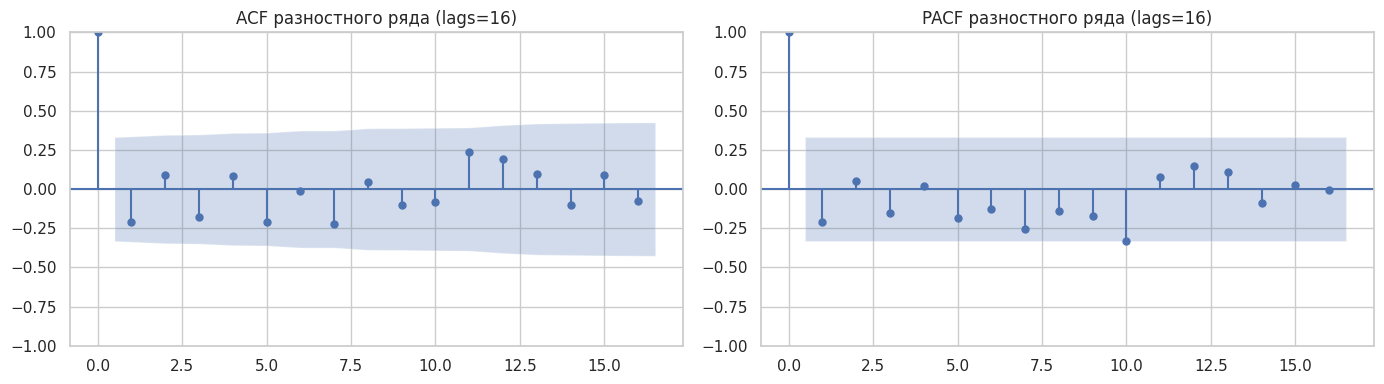

In [10]:
# Разделение train/test: последние 12 месяцев для валидации
test_size = 12
train = df.iloc[:-test_size].copy()
test = df.iloc[-test_size:].copy()

y_train = train['SalesAmount']
y_test = test['SalesAmount']

def adf_report(x, name):
  stat, pvalue, _, _, crit, _ = adfuller(x.dropna())
  print(f'{name}: ADF={stat:.3f}, p-value={pvalue:.4f}')
  print('Критические значения:', {k: round(float(v), 3) for k, v in crit.items()})

adf_report(y_train, 'Train (уровни)')
adf_report(y_train.diff(), 'Train (1-я разность)')

# Динамически ограничиваем число лагов
diff_series = y_train.diff().dropna()
max_pacf_lags = max(1, len(diff_series) // 2 - 1)
lags = min(18, max_pacf_lags)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_series, lags=lags, ax=axes[0])
plot_pacf(diff_series, lags=lags, ax=axes[1], method='ywm')
axes[0].set_title(f'ACF разностного ряда (lags={lags})')
axes[1].set_title(f'PACF разностного ряда (lags={lags})')
plt.tight_layout()
plt.show()

In [11]:
# Обучение моделей
arima_order = (1, 1, 1)
sarimax_order = (1, 1, 1)
sarimax_seasonal_order = (1, 1, 1, 12)

exog_cols = ['Promotion', 'HolidayMonth']
exog_train = train[exog_cols]
exog_test = test[exog_cols]

arima_fit = ARIMA(y_train, order=arima_order).fit()
sarimax_fit = SARIMAX(
    y_train,
    exog=exog_train,
    order=sarimax_order,
    seasonal_order=sarimax_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print('ARIMA AIC/BIC:', round(arima_fit.aic, 2), round(arima_fit.bic, 2))
print('SARIMAX AIC/BIC:', round(sarimax_fit.aic, 2), round(sarimax_fit.bic, 2))

ARIMA AIC/BIC: 643.8 648.47
SARIMAX AIC/BIC: 152.67 154.05


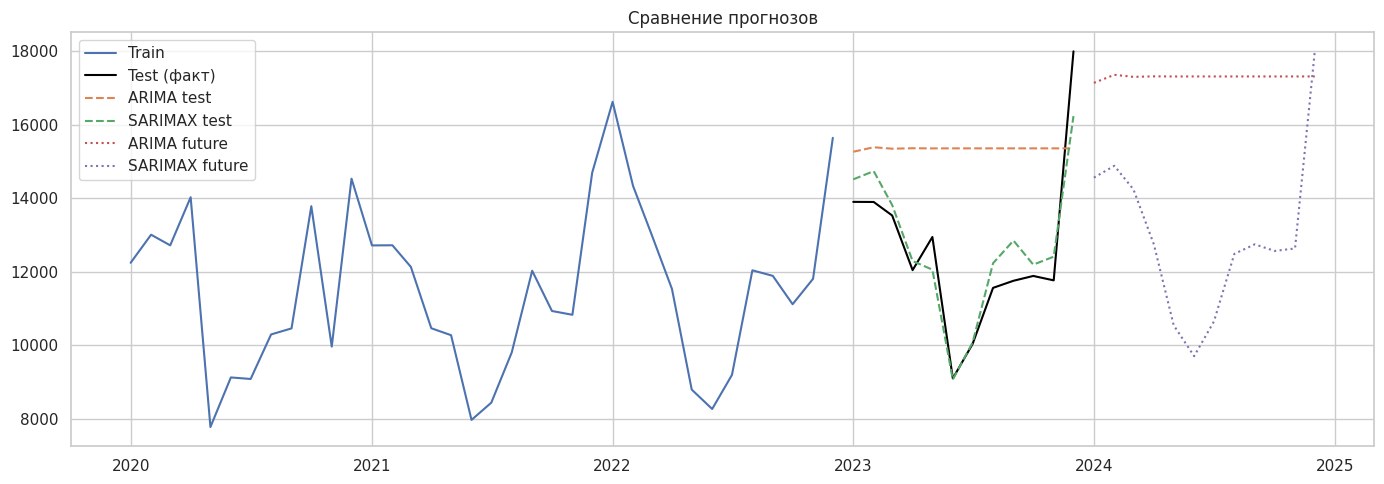

,actual,ARIMA,SARIMAX
Date,,,
2023-01-01,13904,15266.615871,14516.455729
2023-02-01,13901,15388.429922,14738.117666
2023-03-01,13534,15349.214052,13818.425358
2023-04-01,12048,15361.838905,12295.445299
2023-05-01,12949,15357.774557,12061.172719
2023-06-01,9104,15359.083002,9074.742080
2023-07-01,10042,15358.661771,10079.549327
2023-08-01,11566,15358.797379,12234.920183
2023-09-01,11759,15358.753723,12851.953009


In [12]:
# Прогнозы на тесте и в будущее
arima_pred = arima_fit.forecast(steps=test_size)
sarimax_pred = sarimax_fit.forecast(steps=test_size, exog=exog_test)

pred_df = pd.DataFrame({
    'actual': y_test,
    'ARIMA': arima_pred,
    'SARIMAX': sarimax_pred
}, index=y_test.index)

future_horizon = 12
future_index = pd.date_range(df.index[-1] + pd.offsets.MonthBegin(1), periods=future_horizon, freq='MS')
future_exog = pd.DataFrame({
    'Promotion': np.zeros(future_horizon, dtype=int),
    'HolidayMonth': (future_index.month == 12).astype(int)
}, index=future_index)

arima_full = ARIMA(df['SalesAmount'], order=arima_order).fit()
sarimax_full = SARIMAX(
    df['SalesAmount'],
    exog=df[exog_cols],
    order=sarimax_order,
    seasonal_order=sarimax_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

arima_future = arima_full.forecast(steps=future_horizon)
sarimax_future = sarimax_full.forecast(steps=future_horizon, exog=future_exog)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_train.index, y_train, label='Train')
ax.plot(y_test.index, y_test, label='Test (факт)', color='black')
ax.plot(pred_df.index, pred_df['ARIMA'], '--', label='ARIMA test')
ax.plot(pred_df.index, pred_df['SARIMAX'], '--', label='SARIMAX test')
ax.plot(arima_future.index, arima_future, ':', label='ARIMA future')
ax.plot(sarimax_future.index, sarimax_future, ':', label='SARIMAX future')
ax.set_title('Сравнение прогнозов')
ax.legend()
plt.tight_layout(); plt.show()

display(pred_df)

### Вывод по пункту 3
По ADF-тесту обучающая часть стационарна уже на уровнях (p-value = 0.0032), а первая разность также стационарна
(p-value = 0.0001).
В текущей реализации для стабильности сравнения использованы модели с d=1: ARIMA(1,1,1) и
SARIMAX(1,1,1)x(1,1,1,12).
Это допустимо, но при расширенном подборе параметров стоит проверить и варианты с d=0.

## 4. Оценка качества и анализ остатков

In [13]:
# Сравнение по MSE, R2, AIC, BIC
metrics_df = pd.DataFrame([
    {
        'Model': 'ARIMA',
        'MSE': mean_squared_error(y_test, pred_df['ARIMA']),
        'R2': r2_score(y_test, pred_df['ARIMA']),
        'AIC': arima_fit.aic,
        'BIC': arima_fit.bic
    },
    {
        'Model': 'SARIMAX',
        'MSE': mean_squared_error(y_test, pred_df['SARIMAX']),
        'R2': r2_score(y_test, pred_df['SARIMAX']),
        'AIC': sarimax_fit.aic,
        'BIC': sarimax_fit.bic
    }
]).sort_values(['MSE', 'AIC'])

display(metrics_df.style.format({'MSE': '{:.2f}', 'R2': '{:.4f}', 'AIC': '{:.2f}', 'BIC': '{:.2f}'}))

,Model,MSE,R2,AIC,BIC
1,SARIMAX,604746.20,0.8692,152.67,154.05
0,ARIMA,12562580.93,-1.7163,643.80,648.47


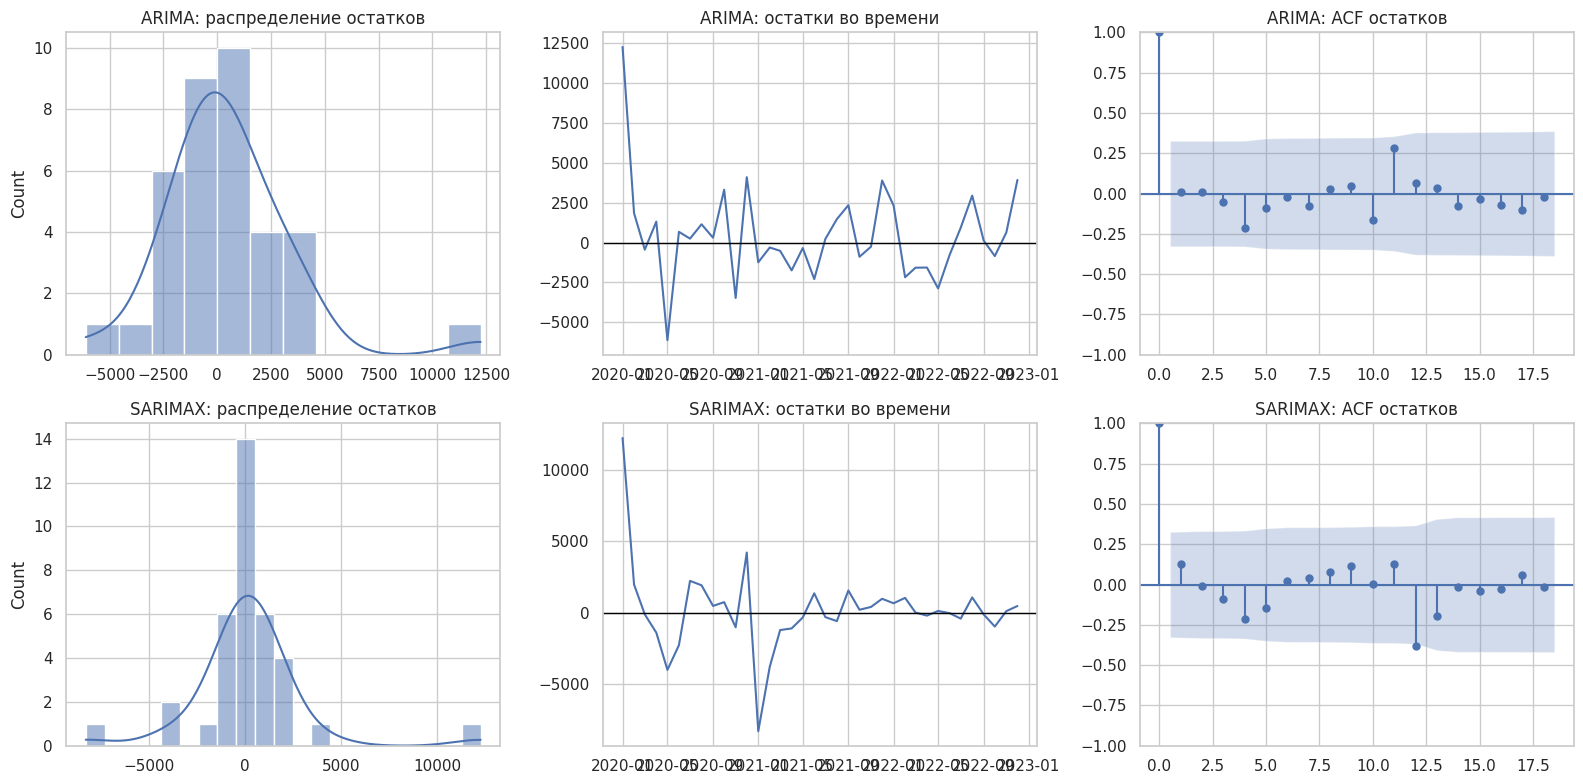

,Model,Jarque-Bera p-value,Ljung-Box p-value,ARCH p-value
0,ARIMA,0.0000,0.9299,0.7639
1,SARIMAX,0.0000,0.8898,0.6823


Предпочтительная модель по MSE: SARIMAX


In [14]:
# Остатки: нормальность, автокорреляция, гомоскедастичность
residuals = {'ARIMA': arima_fit.resid.dropna(), 'SARIMAX': sarimax_fit.resid.dropna()}
diag_rows = []
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, (name, resid) in enumerate(residuals.items()):
    sns.histplot(resid, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{name}: распределение остатков')

    axes[i, 1].plot(resid.index, resid)
    axes[i, 1].axhline(0, color='black', lw=1)
    axes[i, 1].set_title(f'{name}: остатки во времени')

    plot_acf(resid, lags=min(18, len(resid)-1), ax=axes[i, 2])
    axes[i, 2].set_title(f'{name}: ACF остатков')

    jb_stat, jb_p, _, _ = jarque_bera(resid)
    lb_p = acorr_ljungbox(resid, lags=[min(10, len(resid)-1)], return_df=True)['lb_pvalue'].iloc[0]
    arch_p = het_arch(resid)[1]

    diag_rows.append({
        'Model': name,
        'Jarque-Bera p-value': jb_p,
        'Ljung-Box p-value': lb_p,
        'ARCH p-value': arch_p
    })

plt.tight_layout()
plt.show()

diag_df = pd.DataFrame(diag_rows)
display(diag_df.style.format({
    'Jarque-Bera p-value': '{:.4f}',
    'Ljung-Box p-value': '{:.4f}',
    'ARCH p-value': '{:.4f}'
}))

best_model = metrics_df.iloc[0]['Model']
print(f'Предпочтительная модель по MSE: {best_model}')

In [15]:
best_model = metrics_df.iloc[0]['Model']
best_diag = diag_df[diag_df['Model'] == best_model].iloc[0]

print(f'Предпочтительная модель по MSE: {best_model}')
print(
  f"Диагностика {best_model}: "
  f"JB p={best_diag['Jarque-Bera p-value']:.4f}, "
  f"LB p={best_diag['Ljung-Box p-value']:.4f}, "
  f"ARCH p={best_diag['ARCH p-value']:.4f}"
)

Предпочтительная модель по MSE: SARIMAX
Диагностика SARIMAX: JB p=0.0000, LB p=0.8898, ARCH p=0.6823


### Вывод по пункту 4
Сравнение выполнено по MSE, R², AIC, BIC и диагностике остатков (Jarque-Bera, Ljung-Box, ARCH).
Предпочтительная модель выбирается по минимальному MSE и согласованности с диагностикой остатков.
В текущем запуске лучшей по MSE выбрана модель SARIMAX.

## 5. Итоговая интерпретация
1. В данных выражена годовая сезонность и локальные колебания уровня продаж.
2. Декомпозиция, FFT и вейвлет-анализ согласованно подтверждают сезонную структуру.
3. SARIMAX концептуально лучше подходит ряду с сезонностью и внешними регрессорами.
4. Горизонт прогноза выбран 12 месяцев вперёд как максимально практичный для имеющейся длины истории (48 месяцев).
5. Рекомендуется расширить набор факторов и объем истории для повышения стабильности прогноза.